# Coding Assignment 5 

## Problem 1

### Import Data & Prep

In [1]:
import pandas as pd 

data = pd.read_csv("data/Mall_Customers.csv")
data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [2]:
data.shape

(200, 5)

In [3]:
data.dtypes

CustomerID                 int64
Genre                     object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

In [4]:
# Need to convert Genre variable to numerical 
data = pd.get_dummies(data, columns=['Genre'], drop_first=True).astype(int)
data.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Genre_Male
0,1,19,15,39,1
1,2,21,15,81,1
2,3,20,16,6,0
3,4,23,16,77,0
4,5,31,17,40,0


In [14]:
# Standardize features 
from sklearn.preprocessing import StandardScaler

features_to_scale = [
    "Age", 
    "Annual Income (k$)",
    "Spending Score (1-100)",
    "Genre_Male",
]

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data[features_to_scale])
data_scaled = pd.DataFrame(data_scaled, columns=features_to_scale)

# Rename the columns
data_scaled = data_scaled.rename(columns={
    "Genre_Male": "Is Male (scaled)",
    "Annual Income (k$)": "Annual Income (scaled)",
    "Age": "Age (scaled)",
    "Spending Score (1-100)": "Spending Score (scaled)",
})

data_scaled.head()

,Age (scaled),Annual Income (scaled),Spending Score (scaled),Is Male (scaled)
0,-1.424569,-1.738999,-0.434801,1.128152
1,-1.281035,-1.738999,1.195704,1.128152
2,-1.352802,-1.700830,-1.715913,-0.886405
3,-1.137502,-1.700830,1.040418,-0.886405
4,-0.563369,-1.662660,-0.395980,-0.886405


### Part a
#### i. Determine optimal k using the Gap Statistic and the Silhouette Statistic 

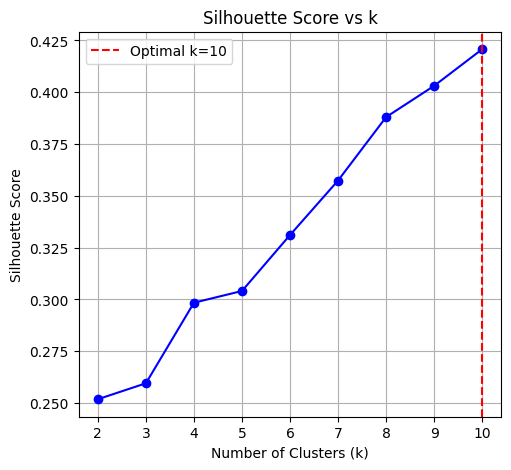

In [17]:

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np
import matplotlib.pyplot as plt

# Test range of k values
k_range = range(2, 11)
silhouette_scores = []
inertias = []

X = data_scaled

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    
    silhouette_scores.append(silhouette_score(X, labels))
    inertias.append(kmeans.inertia_)

# Plot Silhouette Scores
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, silhouette_scores, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs k')
ksil = k_range[np.argmax(silhouette_scores)]
plt.axvline(x=ksil, color='r', linestyle='--', label=f'Optimal k={ksil}')
plt.legend()
plt.grid()

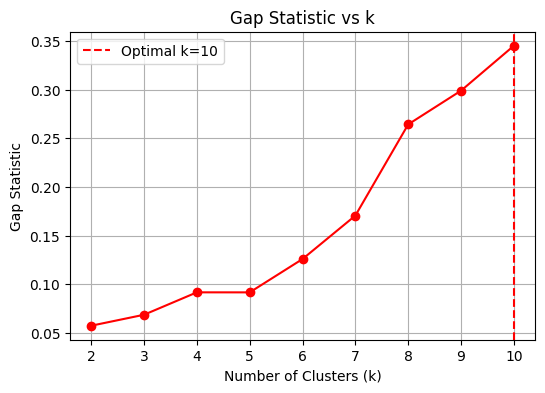

In [19]:
# Calculate Gap Statistic
def gap_statistic(X, k_range):
    gap_values = []
    
    for k in k_range:
        # Fit K-means
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        
        # Within-cluster dispersion
        W_k = kmeans.inertia_
        
        # Generate random data and calculate dispersion
        B_k = 0
        for _ in range(10):
            random_data = np.random.uniform(X.min(axis=0), X.max(axis=0), X.shape)
            kmeans_random = KMeans(n_clusters=k, random_state=42, n_init=10)
            B_k += kmeans_random.fit(random_data).inertia_
        
        B_k /= 10
        gap_values.append(np.log(B_k) - np.log(W_k))
    
    return gap_values

gap_stats = gap_statistic(X, k_range)
kgap = k_range[np.argmax(gap_stats)]

plt.figure(figsize=(6, 4))
plt.plot(k_range, gap_stats, 'ro-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Gap Statistic')
plt.title('Gap Statistic vs k')
plt.axvline(x=kgap, color='r', linestyle='--', label=f'Optimal k={kgap}')
plt.legend()
plt.grid()
plt.show()

In [20]:
print(f"Optimal k from Gap Statistic: {kgap}")
print(f"Optimal k from Silhouette Score: {ksil}")

Optimal k from Gap Statistic: 10
Optimal k from Silhouette Score: 10


#### ii. Plot Annual Income vs. Spending Score

Because the optimal k is 10 using both statistics, there is only one plot: 

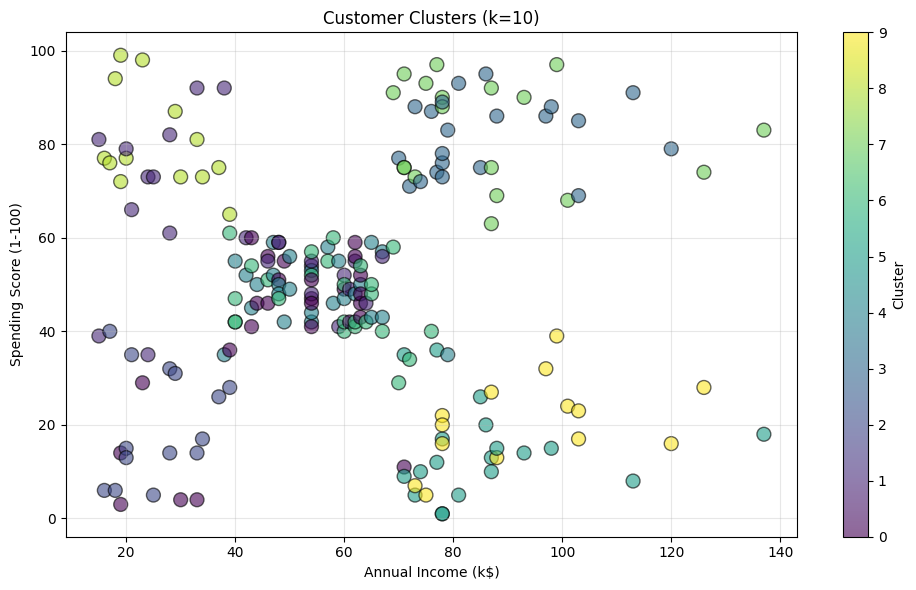

In [28]:
# Fit K-means with optimal k
kmeans = KMeans(n_clusters=kgap, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

# Plot Annual Income vs. Spending Score
plt.figure(figsize=(10, 6))
scatter = plt.scatter(data["Annual Income (k$)"], 
                      data["Spending Score (1-100)"], 
                      c=labels, cmap='viridis', s=100, alpha=0.6, edgecolors='k')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title(f'Customer Clusters (k={kgap})')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

There is poor separability among these clusters. The clusters show significant overlap, especially in the middle income range ($40-70k). The more extreme clusters are more separable. High-income/high-spending, low-income/low-spending, and high-income/low-spending customers show some separation.

#### iii. Interpretation of the clusters

In [ ]:
# Add cluster labels to original data
data_with_clusters = data.copy()
data_with_clusters['Cluster'] = labels

# Compute summary statistics for each cluster
print(f"Summary Statistics for Each Cluster (k={kgap}):\n")
print("="*80)

for cluster in range(kgap):
    cluster_data = data_with_clusters[data_with_clusters['Cluster'] == cluster]
    
    print(f"\nCluster {cluster} (n={len(cluster_data)} customers):")
    print(f"  Annual Income:     Mean=${cluster_data['Annual Income (k$)'].mean():.2f}k, "
          f"Std=${cluster_data['Annual Income (k$)'].std():.2f}k")
    print(f"  Spending Score:    Mean={cluster_data['Spending Score (1-100)'].mean():.2f}, "
          f"Std={cluster_data['Spending Score (1-100)'].std():.2f}")
    print(f"  Age:               Mean={cluster_data['Age'].mean():.2f}, "
          f"Std={cluster_data['Age'].std():.2f}")
    print(f"  Gender (% Male):   {(cluster_data['Genre_Male'].sum() / len(cluster_data) * 100):.1f}%")

Summary Statistics for Each Cluster (k=10):


Cluster 0 (n=26 customers):
  Annual Income:     Mean=$48.69k, Std=$14.53k
  Spending Score:    Mean=39.85, Std=17.72
  Age:               Mean=58.85, Std=8.05
  Gender (% Male):   100.0%

Cluster 1 (n=24 customers):
  Annual Income:     Mean=$41.25k, Std=$17.19k
  Spending Score:    Mean=60.92, Std=15.84
  Age:               Mean=25.25, Std=6.86
  Gender (% Male):   100.0%

Cluster 2 (n=14 customers):
  Annual Income:     Mean=$26.07k, Std=$7.66k
  Spending Score:    Mean=20.14, Std=11.64
  Age:               Mean=41.21, Std=9.93
  Gender (% Male):   7.1%

Cluster 3 (n=21 customers):
  Annual Income:     Mean=$86.05k, Std=$14.16k
  Spending Score:    Mean=81.67, Std=7.83
  Age:               Mean=32.19, Std=3.08
  Gender (% Male):   0.0%

Cluster 4 (n=26 customers):
  Annual Income:     Mean=$54.23k, Std=$9.96k
  Spending Score:    Mean=48.96, Std=6.70
  Age:               Mean=54.15, Std=7.82
  Gender (% Male):   0.0%

Cluster 5 (n=19 cus

In [32]:
# Overall summary
print("Overall Summary:")
print(f"  Total Customers: {len(data_with_clusters)}")
print(f"  Cluster Sizes: {np.bincount(labels)}")

Overall Summary:
  Total Customers: 200
  Cluster Sizes: [26 24 14 21 26 19 25 18 13 14]


High-Value Customer Segments:

- **Cluster 3 & 7 (High Income, High Spending)**: These are the most valuable customers with income ~$86-87k and spending scores ~82. Cluster 3 is predominantly female (0% male), while Cluster 7 is all male. Both are young (32-33 years old).

- **Cluster 8 (Low Income, High Spending)**: Young females (avg 25 years) with low income ($26k) but high spending scores (81). These are budget-conscious but enthusiastic shoppers.

Low-Value Customer Segments:

- **Cluster 5 & 9 (High Income, Low Spending)**: Affluent but conservative spenders. Both have high incomes ($86-93k) but low spending scores (14-21). Cluster 5 is all male, Cluster 9 is all female. These represent untapped potential.

- **Cluster 2 (Low Income, Low Spending)**: Predominantly female (93% female) with lowest income ($26k) and low spending (20). Limited purchasing power.

Middle-Market Segments:

- **Clusters 0, 4, 6 (Mid-Range)**: Moderate income ($48-57k) and moderate spending (47-49). Cluster 0 is older males, Cluster 4 is older females, Cluster 6 is younger females. Stable but not high-value.

- **Cluster 1 (Young, Mid-Income, High Spending)**: Young males (25 years) with moderate income ($41k) but decent spending (61). Potential growth segment.


Key Insights: 

- There is a clear gender segmentation. Males dominate low-spending clusters despite higher income. 

- Younger customers (25-33) tend to spend more; older customers are more conservative. 

- High income doesn't always mean high spending. 

### Part b

#### i. Dendrogram plot

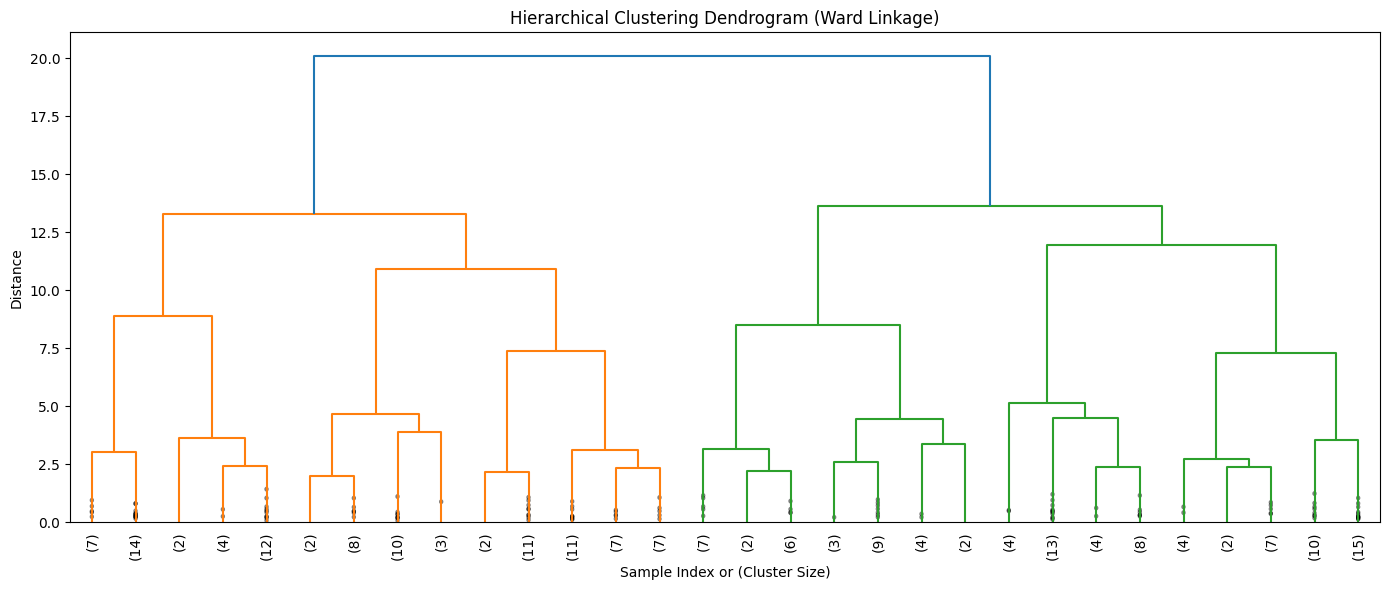

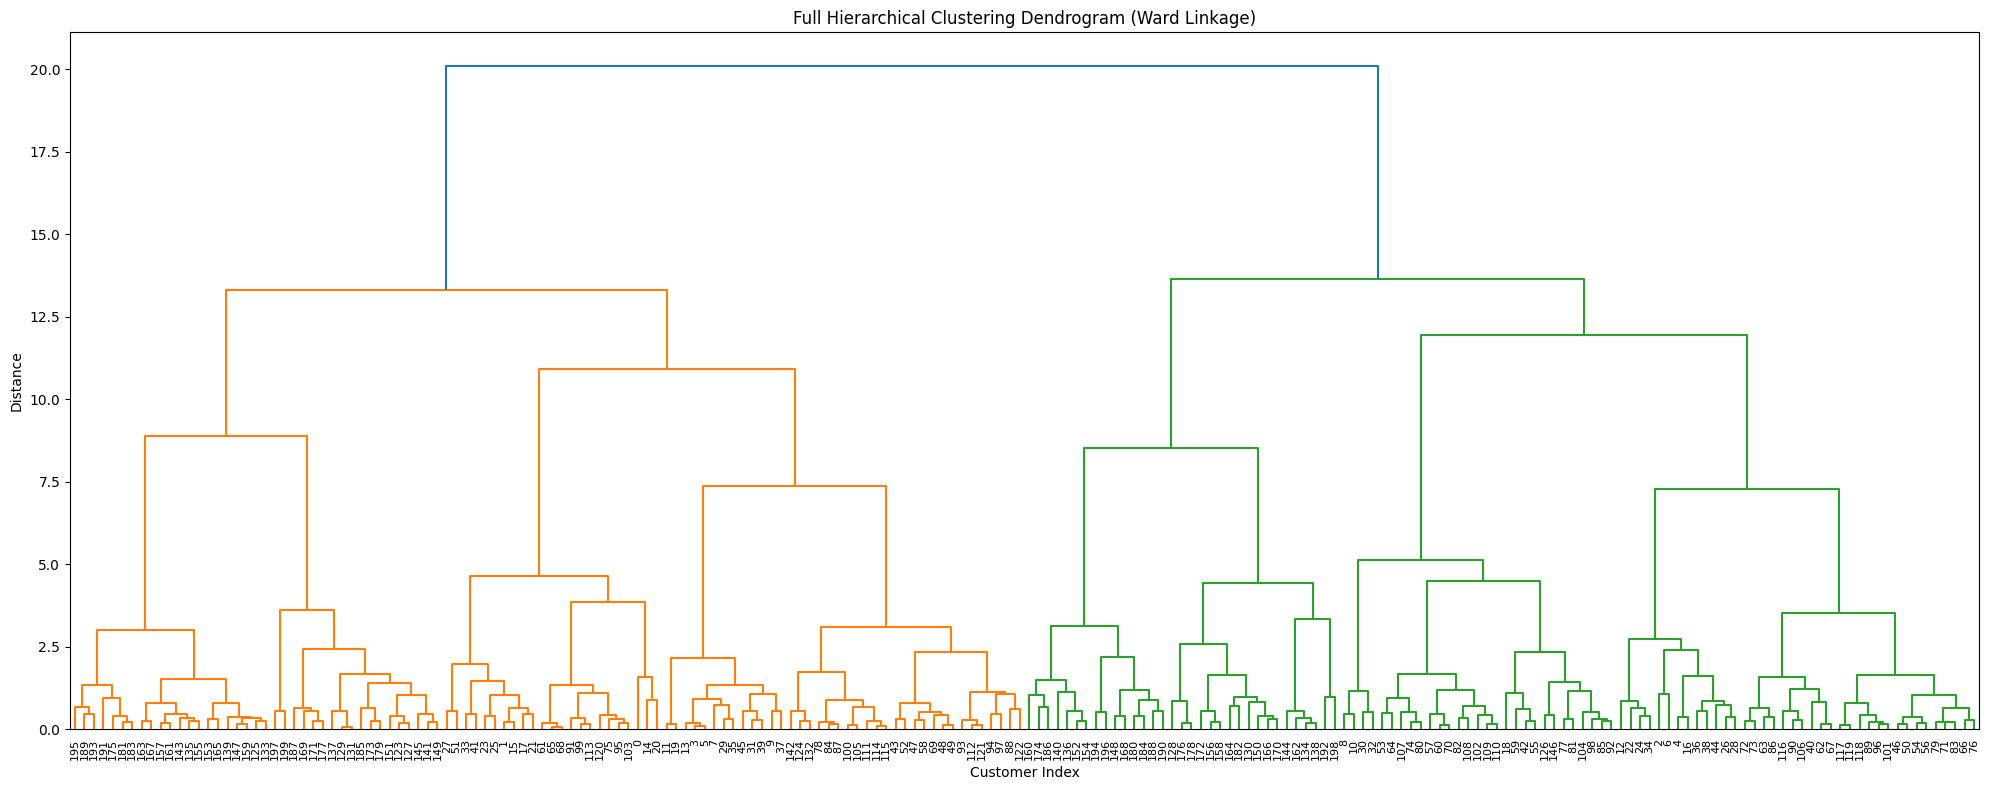

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

# Perform hierarchical clustering 
linkage_matrix = linkage(X, method='ward')

# Create dendrogram
plt.figure(figsize=(14, 6))
dendrogram(linkage_matrix, 
           truncate_mode='lastp',
           p=30,  # show only the last 30 merged clusters
           leaf_rotation=90,
           leaf_font_size=10,
           show_contracted=True)
plt.xlabel('Sample Index or (Cluster Size)')
plt.ylabel('Distance')
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.tight_layout()
plt.show()

# Full dendrogram 
plt.figure(figsize=(20, 8))
dendrogram(linkage_matrix, leaf_rotation=90, leaf_font_size=8)
plt.xlabel('Customer Index')
plt.ylabel('Distance')
plt.title('Full Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.tight_layout()
plt.show()

#### ii. Plot Annual Income vs. Spending Score

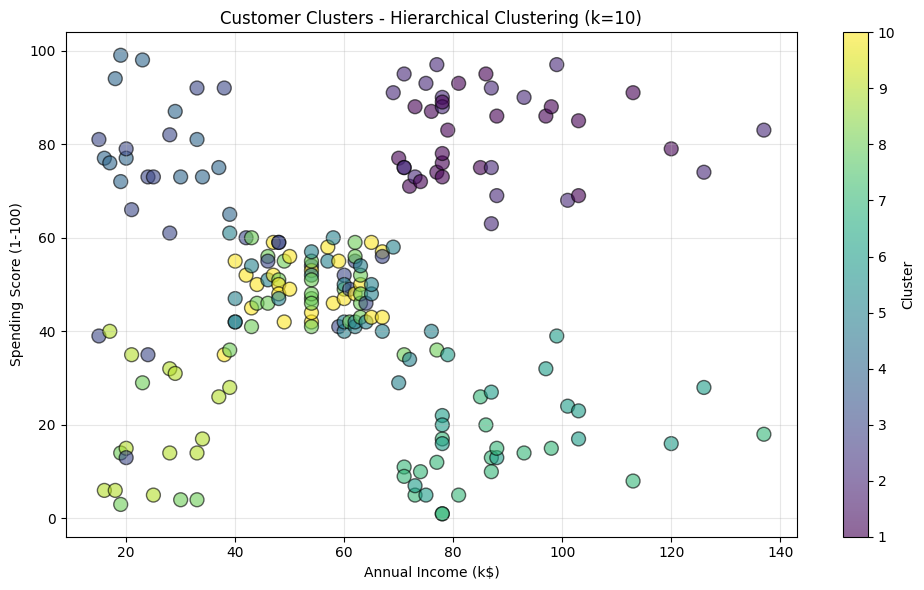

In [34]:
from scipy.cluster.hierarchy import fcluster

# Cut the dendrogram to create k clusters (use same k as k-means for comparison)
hc_labels = fcluster(linkage_matrix, kgap, criterion='maxclust')

# Plot Annual Income vs. Spending Score with hierarchical clusters
plt.figure(figsize=(10, 6))
scatter = plt.scatter(data["Annual Income (k$)"], 
                      data["Spending Score (1-100)"], 
                      c=hc_labels, cmap='viridis', s=100, alpha=0.6, edgecolors='k')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title(f'Customer Clusters - Hierarchical Clustering (k={kgap})')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Add hierarchical cluster labels to data
data_hc_clusters = data.copy()
data_hc_clusters['Cluster'] = hc_labels

#### Interpretation of the clusters


In [35]:
# Add hierarchical cluster labels to original data
data_hc_with_clusters = data.copy()
data_hc_with_clusters['Cluster'] = hc_labels

# Compute summary statistics for each hierarchical cluster
print(f"Summary Statistics for Hierarchical Clusters (k={kgap}):\n")
print("="*80)

for cluster in range(1, kgap + 1):
    cluster_data = data_hc_with_clusters[data_hc_with_clusters['Cluster'] == cluster]
    
    print(f"\nCluster {cluster} (n={len(cluster_data)} customers):")
    print(f"  Annual Income:     Mean=${cluster_data['Annual Income (k$)'].mean():.2f}k, "
          f"Std=${cluster_data['Annual Income (k$)'].std():.2f}k")
    print(f"  Spending Score:    Mean={cluster_data['Spending Score (1-100)'].mean():.2f}, "
          f"Std={cluster_data['Spending Score (1-100)'].std():.2f}")
    print(f"  Age:               Mean={cluster_data['Age'].mean():.2f}, "
          f"Std={cluster_data['Age'].std():.2f}")
    print(f"  Gender (% Male):   {(cluster_data['Genre_Male'].sum() / len(cluster_data) * 100):.1f}%")

# Overall summary
print("\n" + "="*80)
print("Overall Summary:")
print(f"  Total Customers: {len(data_hc_with_clusters)}")
print(f"  Cluster Sizes: {np.bincount(hc_labels)}")

Summary Statistics for Hierarchical Clusters (k=10):


Cluster 1 (n=21 customers):
  Annual Income:     Mean=$86.05k, Std=$14.16k
  Spending Score:    Mean=81.67, Std=7.83
  Age:               Mean=32.19, Std=3.08
  Gender (% Male):   0.0%

Cluster 2 (n=18 customers):
  Annual Income:     Mean=$87.11k, Std=$18.93k
  Spending Score:    Mean=82.67, Std=11.10
  Age:               Mean=33.28, Std=4.39
  Gender (% Male):   100.0%

Cluster 3 (n=23 customers):
  Annual Income:     Mean=$39.22k, Std=$17.62k
  Spending Score:    Mean=59.65, Std=18.86
  Age:               Mean=24.57, Std=6.14
  Gender (% Male):   100.0%

Cluster 4 (n=13 customers):
  Annual Income:     Mean=$25.69k, Std=$8.24k
  Spending Score:    Mean=80.54, Std=10.70
  Age:               Mean=25.46, Std=5.22
  Gender (% Male):   0.0%

Cluster 5 (n=25 customers):
  Annual Income:     Mean=$57.36k, Std=$10.98k
  Spending Score:    Mean=47.12, Std=8.19
  Age:               Mean=27.96, Std=6.67
  Gender (% Male):   0.0%

Cluster 6

**Comparison with K-Means**: 
 
Hierarchical clustering shows pretty similar poor clustering like K-Means. There is still significant overlap in the middle income range. However, the color distribution looks more gradual and continuous suggesting hierarchical clustering creates more natural groupings. 

Both methods identify high-income, high-spending clusters, but the hierarchical cluster are larger. Hierarchical clustering also has a clearer gender segmentation. 

Overall, the hierarchical clusters have a clearer segment narrative which is beneficial for real-life business purposes.

## Problem 2

### Create the moons synthetic data

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

Two Moons Dataset:
          X         Y  Label
0 -0.016988  0.397237      1
1  0.694613 -0.427054      1
2  0.847768  0.519621      0
3  0.095624  0.305824      1
4  0.097075  0.970429      0
5  0.321911  0.948514      0
6  1.412426 -0.422415      1
7  0.079933  0.956558      0
8  0.477027 -0.355522      1
9 -0.412030  0.955345      0

Dataset shape: (400, 3)

Label distribution:
Label
0    200
1    200
Name: count, dtype: int64


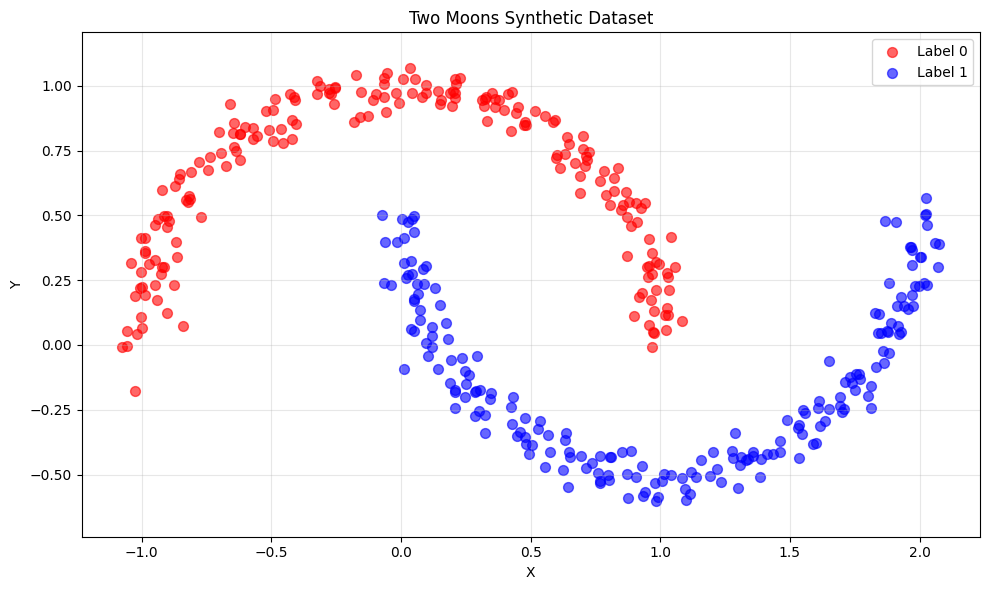

In [ ]:
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(n_samples=400, noise=0.05, random_state=42)

moons_df = pd.DataFrame({
    'X': X_moons[:, 0],
    'Y': X_moons[:, 1],
    'Label': y_moons
})

print("Two Moons Dataset:")
print(moons_df.head(10))
print(f"\nDataset shape: {moons_df.shape}")
print(f"\nLabel distribution:\n{moons_df['Label'].value_counts().sort_index()}")

plt.figure(figsize=(10, 6))
plt.scatter(moons_df[moons_df['Label'] == 0]['X'], 
            moons_df[moons_df['Label'] == 0]['Y'], 
            c='red', label='Label 0', alpha=0.6, s=50)
plt.scatter(moons_df[moons_df['Label'] == 1]['X'], 
            moons_df[moons_df['Label'] == 1]['Y'], 
            c='blue', label='Label 1', alpha=0.6, s=50)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Two Moons Synthetic Dataset')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.show()

### Part a

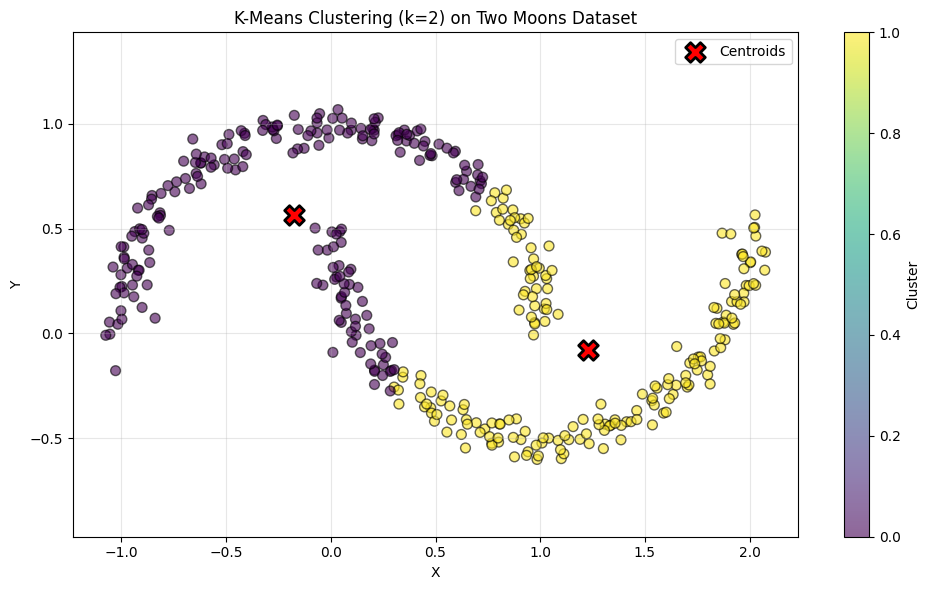

In [23]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_moons)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_moons[:, 0], X_moons[:, 1], 
                      c=kmeans_labels, cmap='viridis', s=50, alpha=0.6, edgecolors='k')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            c='red', marker='X', s=200, edgecolors='black', linewidth=2, label='Centroids')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('K-Means Clustering (k=2) on Two Moons Dataset')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.show()


K-Means doesn't perform very well on this dataset. It is not able to recognize the two convex clusters. Many points are misclassified. 

### Part b

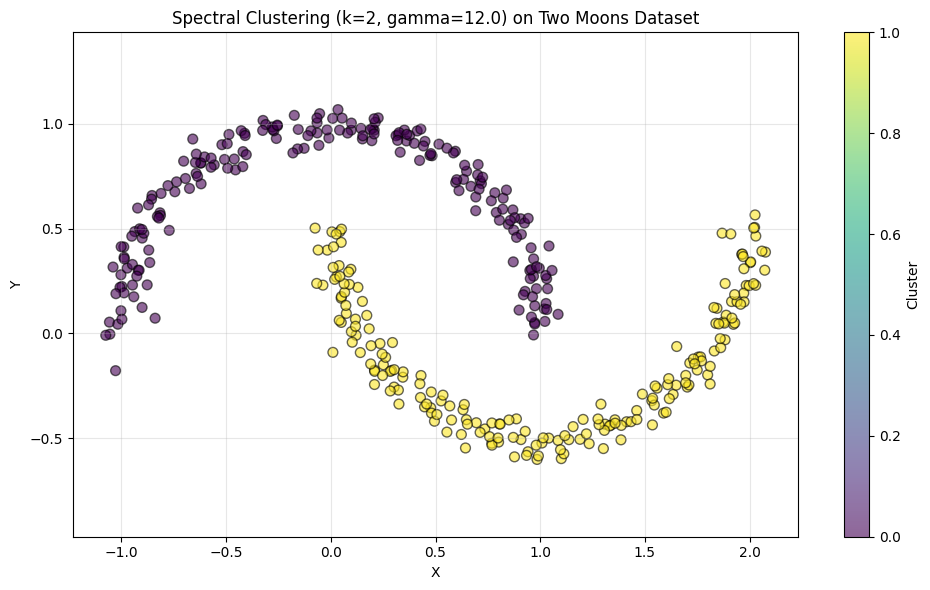

In [ ]:
from sklearn.cluster import SpectralClustering

# Apply Spectral Clustering with tuned gamma parameter
spectral = SpectralClustering(
    n_clusters=2, 
    affinity='rbf', 
    gamma=12.0,  # I kept increasing the gamma value until I got properly classified clusters
    random_state=42, 
    n_init=10
)
spectral_labels = spectral.fit_predict(X_moons)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_moons[:, 0], X_moons[:, 1], 
                      c=spectral_labels, cmap='viridis', s=50, alpha=0.6, edgecolors='k')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Spectral Clustering (k=2, gamma=12.0) on Two Moons Dataset')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.show()


Using Spectral Clustering, the crescents are classified much more accurately. There is a clear separation between the two crescents. K-Means were misclassifying within both crescents. 